# Topological Summaries
## Beyond persistence diagrams — vectorizing topology for machine learning

Persistence diagrams are not directly usable as features in standard ML models — they are sets of points with variable cardinality. **Topological summaries** are stable, vectorizable representations derived from persistence diagrams that bridge TDA and machine learning.

In this notebook we cover three key summaries:

- **Persistence Landscapes** — functional representation of a persistence diagram
- **Persistence Entropy** — information-theoretic complexity measure
- **Bottleneck Distance** — a metric on the space of persistence diagrams

These are the building blocks for feeding topological features into financial predictive models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams, bottleneck
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, PersistenceEntropy
import warnings
warnings.filterwarnings('ignore')

## Setup — Three Point Clouds

We work with three point clouds of increasing topological complexity to illustrate how each summary behaves across different underlying spaces.

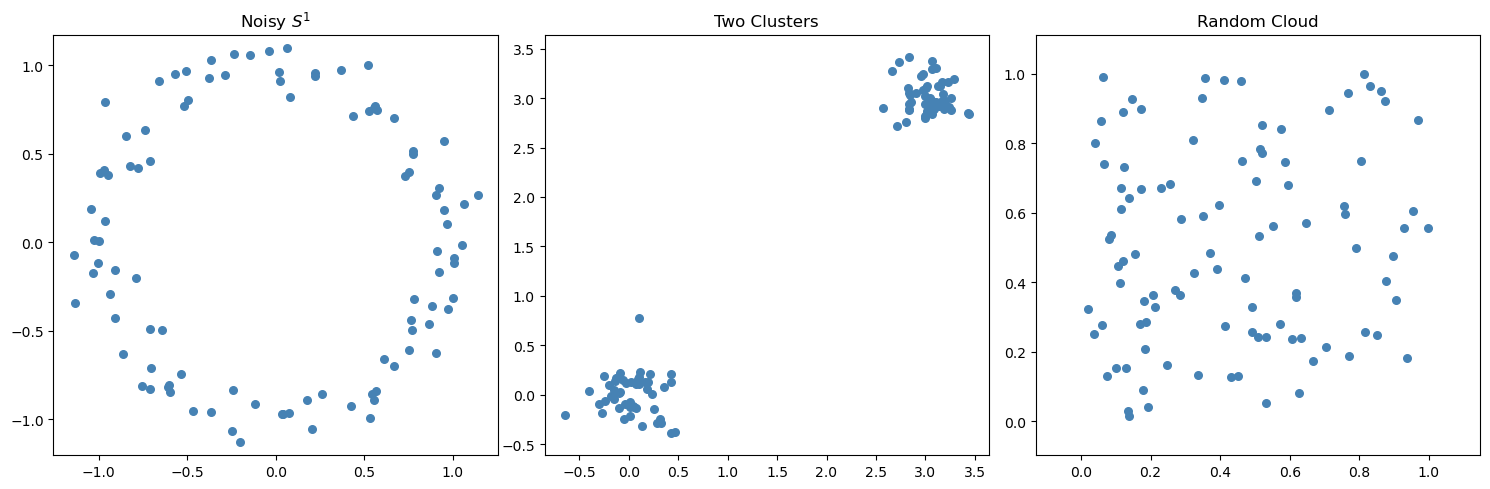

In [2]:
np.random.seed(42)

# Noisy circle
theta = np.linspace(0, 2 * np.pi, 100)
X_circle = np.column_stack([np.cos(theta), np.sin(theta)])
X_circle += np.random.normal(0, 0.1, X_circle.shape)

# Two clusters
cluster1 = np.random.normal(loc=[0, 0], scale=0.2, size=(50, 2))
cluster2 = np.random.normal(loc=[3, 3], scale=0.2, size=(50, 2))
X_clusters = np.vstack([cluster1, cluster2])

# Random cloud
X_random = np.random.rand(100, 2)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, X, title in zip(axes, 
                         [X_circle, X_clusters, X_random],
                         ['Noisy $S^1$', 'Two Clusters', 'Random Cloud']):
    ax.scatter(X[:, 0], X[:, 1], c='steelblue', s=30)
    ax.set_title(title)
    ax.axis('equal')
plt.tight_layout()
plt.show()

## 1. Persistence Landscapes

The persistence landscape $\lambda_k : \mathbb{R} \to \mathbb{R}$ is a functional summary of a persistence diagram defined as:

$$\lambda_k(t) = k\text{-th largest value of } \min(t - b, d - t)_+$$

where $(b, d)$ are birth-death pairs. Key properties:

- **Stable** — small perturbations in the diagram produce small changes in the landscape
- **Vectorizable** — discretized into a fixed-length vector for ML
- **Interpretable** — peaks correspond to the most persistent features

In [7]:
print("Landscapes shape:", landscapes.shape)
print("Diagrams shape:", diagrams_gtda.shape)

Landscapes shape: (3, 4, 100)
Diagrams shape: (3, 114, 3)


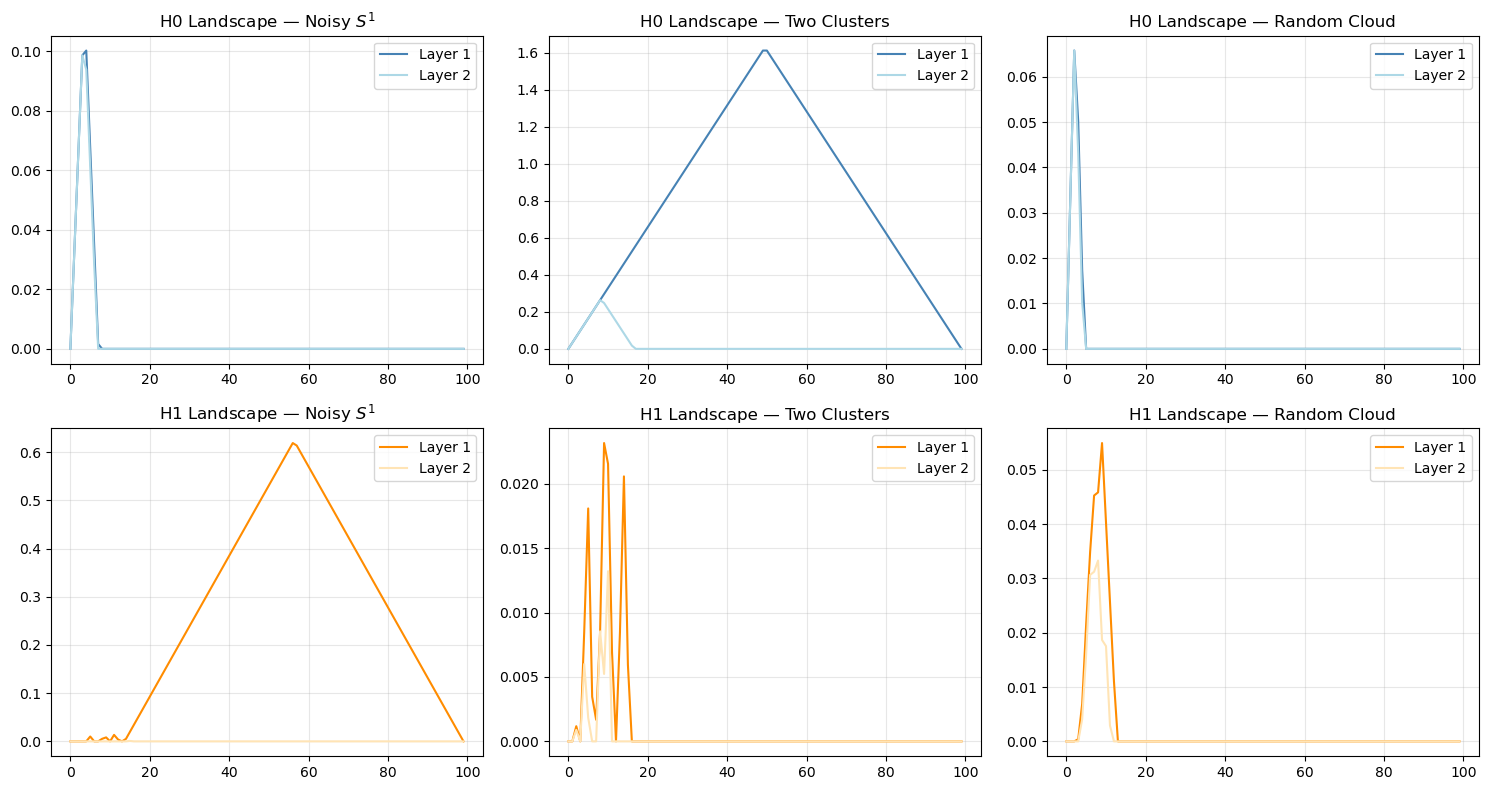

In [8]:
# Separate H0 and H1 landscapes
# layers 0,1 = H0 | layers 2,3 = H1

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
titles = ['Noisy $S^1$', 'Two Clusters', 'Random Cloud']

for i, title in enumerate(titles):
    # H0
    axes[0, i].plot(landscapes[i, 0, :], label='Layer 1', color='steelblue')
    axes[0, i].plot(landscapes[i, 1, :], label='Layer 2', color='lightblue')
    axes[0, i].set_title(f'H0 Landscape — {title}')
    axes[0, i].legend()
    axes[0, i].grid(alpha=0.3)

    # H1
    axes[1, i].plot(landscapes[i, 2, :], label='Layer 1', color='darkorange')
    axes[1, i].plot(landscapes[i, 3, :], label='Layer 2', color='moccasin')
    axes[1, i].set_title(f'H1 Landscape — {title}')
    axes[1, i].legend()
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Persistence Entropy

Persistence entropy measures the **complexity** of a persistence diagram using Shannon entropy applied to the normalized lifetimes of topological features:

$$E = -\sum_{i} p_i \log p_i, \quad p_i = \frac{d_i - b_i}{\sum_j (d_j - b_j)}$$

where $(b_i, d_i)$ are birth-death pairs. 

- **High entropy** → many features with similar persistence → complex, unstructured topology
- **Low entropy** → one dominant feature → clear topological signal

In financial applications, persistence entropy can track **market complexity** over time.

Persistence Entropies (H0, H1):
  Noisy S1: H0=6.4173, H1=0.5343
  Two Clusters: H0=5.1495, H1=3.1712
  Random Cloud: H0=6.4606, H1=3.4780


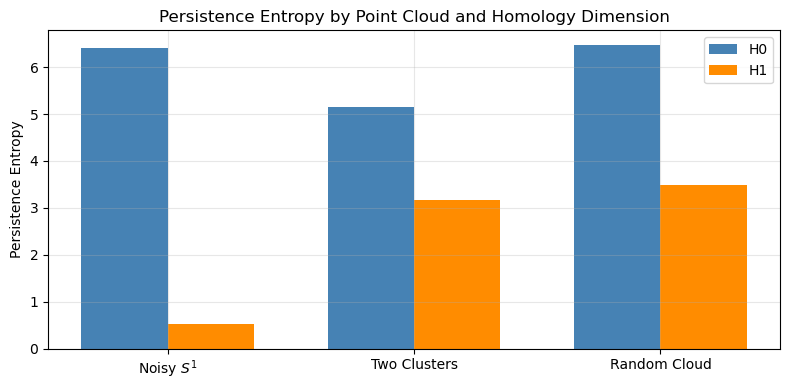

In [9]:
from gtda.diagrams import PersistenceEntropy

PE = PersistenceEntropy()
entropies = PE.fit_transform(diagrams_gtda)

print("Persistence Entropies (H0, H1):")
for title, e in zip(['Noisy S1', 'Two Clusters', 'Random Cloud'], entropies):
    print(f"  {title}: H0={e[0]:.4f}, H1={e[1]:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
width = 0.35
labels = ['Noisy $S^1$', 'Two Clusters', 'Random Cloud']

ax.bar(x - width/2, entropies[:, 0], width, label='H0', color='steelblue')
ax.bar(x + width/2, entropies[:, 1], width, label='H1', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Persistence Entropy')
ax.set_title('Persistence Entropy by Point Cloud and Homology Dimension')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Observations

The persistence entropy values reveal a clear pattern:

| Space | H0 entropy | H1 entropy |
|-------|-----------|-----------|
| Noisy $S^1$ | 6.42 | **0.53** |
| Two Clusters | 5.15 | 3.17 |
| Random Cloud | 6.46 | 3.48 |

**H1 entropy is lowest for the noisy $S^1$** — one dominant loop persists much longer than all other features, concentrating the lifetime distribution and reducing entropy.

**H1 entropy is highest for the random cloud** — many short-lived loops of similar persistence produce a flat lifetime distribution, maximizing entropy.

This has a direct financial interpretation: a sudden **drop in persistence entropy** computed on rolling windows of market returns signals the emergence of a dominant topological feature — a potential precursor to a market regime change or crash, as documented in Gidea & Katz (2018).

In [10]:
# Compute bottleneck distances between persistence diagrams
d_circle_clusters = bottleneck(
    ripser(X_circle)['dgms'][1],
    ripser(X_clusters)['dgms'][1]
)

d_circle_random = bottleneck(
    ripser(X_circle)['dgms'][1],
    ripser(X_random)['dgms'][1]
)

d_clusters_random = bottleneck(
    ripser(X_clusters)['dgms'][1],
    ripser(X_random)['dgms'][1]
)

print("Bottleneck Distances (H1):")
print(f"  Noisy S1 vs Two Clusters : {d_circle_clusters:.4f}")
print(f"  Noisy S1 vs Random Cloud : {d_circle_random:.4f}")
print(f"  Two Clusters vs Random Cloud: {d_clusters_random:.4f}")

Bottleneck Distances (H1):
  Noisy S1 vs Two Clusters : 0.6237
  Noisy S1 vs Random Cloud : 0.6237
  Two Clusters vs Random Cloud: 0.0436


## Observations

| Comparison | $d_B$ (H1) | Interpretation |
|------------|-----------|----------------|
| Noisy $S^1$ vs Two Clusters | 0.6237 | Topologically distant — circle has a persistent loop |
| Noisy $S^1$ vs Random Cloud | 0.6237 | Topologically distant — same reason |
| Two Clusters vs Random Cloud | 0.0436 | Topologically similar — neither has persistent H1 |

The bottleneck distance correctly identifies the noisy $S^1$ as topologically distinct from the other two spaces. In financial applications, $d_B$ computed between consecutive time windows can detect **abrupt topological changes** in market structure — potential early warning signals for regime shifts.

## Conclusions

Three vectorizable topological summaries, each capturing a different aspect of the persistence diagram:

| Summary | What it captures | Financial application |
|---------|-----------------|----------------------|
| Persistence Landscapes | Full functional structure of persistence | Feature vector for ML models |
| Persistence Entropy | Complexity of topological structure | Market complexity, regime detection |
| Bottleneck Distance | Dissimilarity between diagrams | Regime change detection, anomaly detection |

Together these summaries form the **bridge between TDA and quantitative finance** — converting topological information into numerical features that feed directly into predictive models.

This completes the foundations of TDA. The next step is applying these tools to real financial data.